# Lab Day 19: GraphRAG với Tech Company Corpus

Notebook này chạy pipeline từ indexing đến benchmark cho corpus trong `data/corpus.json`.

In [9]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.graphrag_lab import Config, load_corpus, chunk_documents
from src.graphrag_lab import index_pipeline, load_or_build_artifacts
from src.graphrag_lab import ask_flat, ask_graph, run_benchmark

cfg = Config.from_env(ROOT / '.env')
cfg.data_path = ROOT / cfg.data_path
cfg.artifact_dir = ROOT / cfg.artifact_dir

## 2. Khám phá corpus

In [2]:
docs = load_corpus(cfg.data_path)
[(doc.id, doc.title, len(doc.content)) for doc in docs]

[('1', 'OpenAI', 111203),
 ('2', 'Qualcomm', 92562),
 ('3', 'Vingroup', 15085),
 ('4', 'Google', 152572),
 ('5', 'Viettel', 34465)]

In [3]:
chunks = chunk_documents(docs, cfg.chunk_size_words, cfg.chunk_overlap_words, cfg.max_chunks_per_doc)
len(chunks), chunks[0].id, chunks[0].title, chunks[0].text[:500]

(39,
 'doc1_chunk000',
 'OpenAI',
 'American artificial intelligence company Not to be confused with OpenAL , OpenAPI , or Open-source artificial intelligence . OpenAI Global, LLC is an American artificial intelligence (AI) research organization consisting of a for-profit public benefit corporation (PBC) and a nonprofit foundation, headquartered in San Francisco . OpenAI developed the generative pre-trained transformer (GPT) family of large language models , the DALL-E series of text-to-image models , and the Sora series of text-t')

## 3. Indexing và Graph Construction

In [ ]:
metrics = index_pipeline(cfg)
metrics

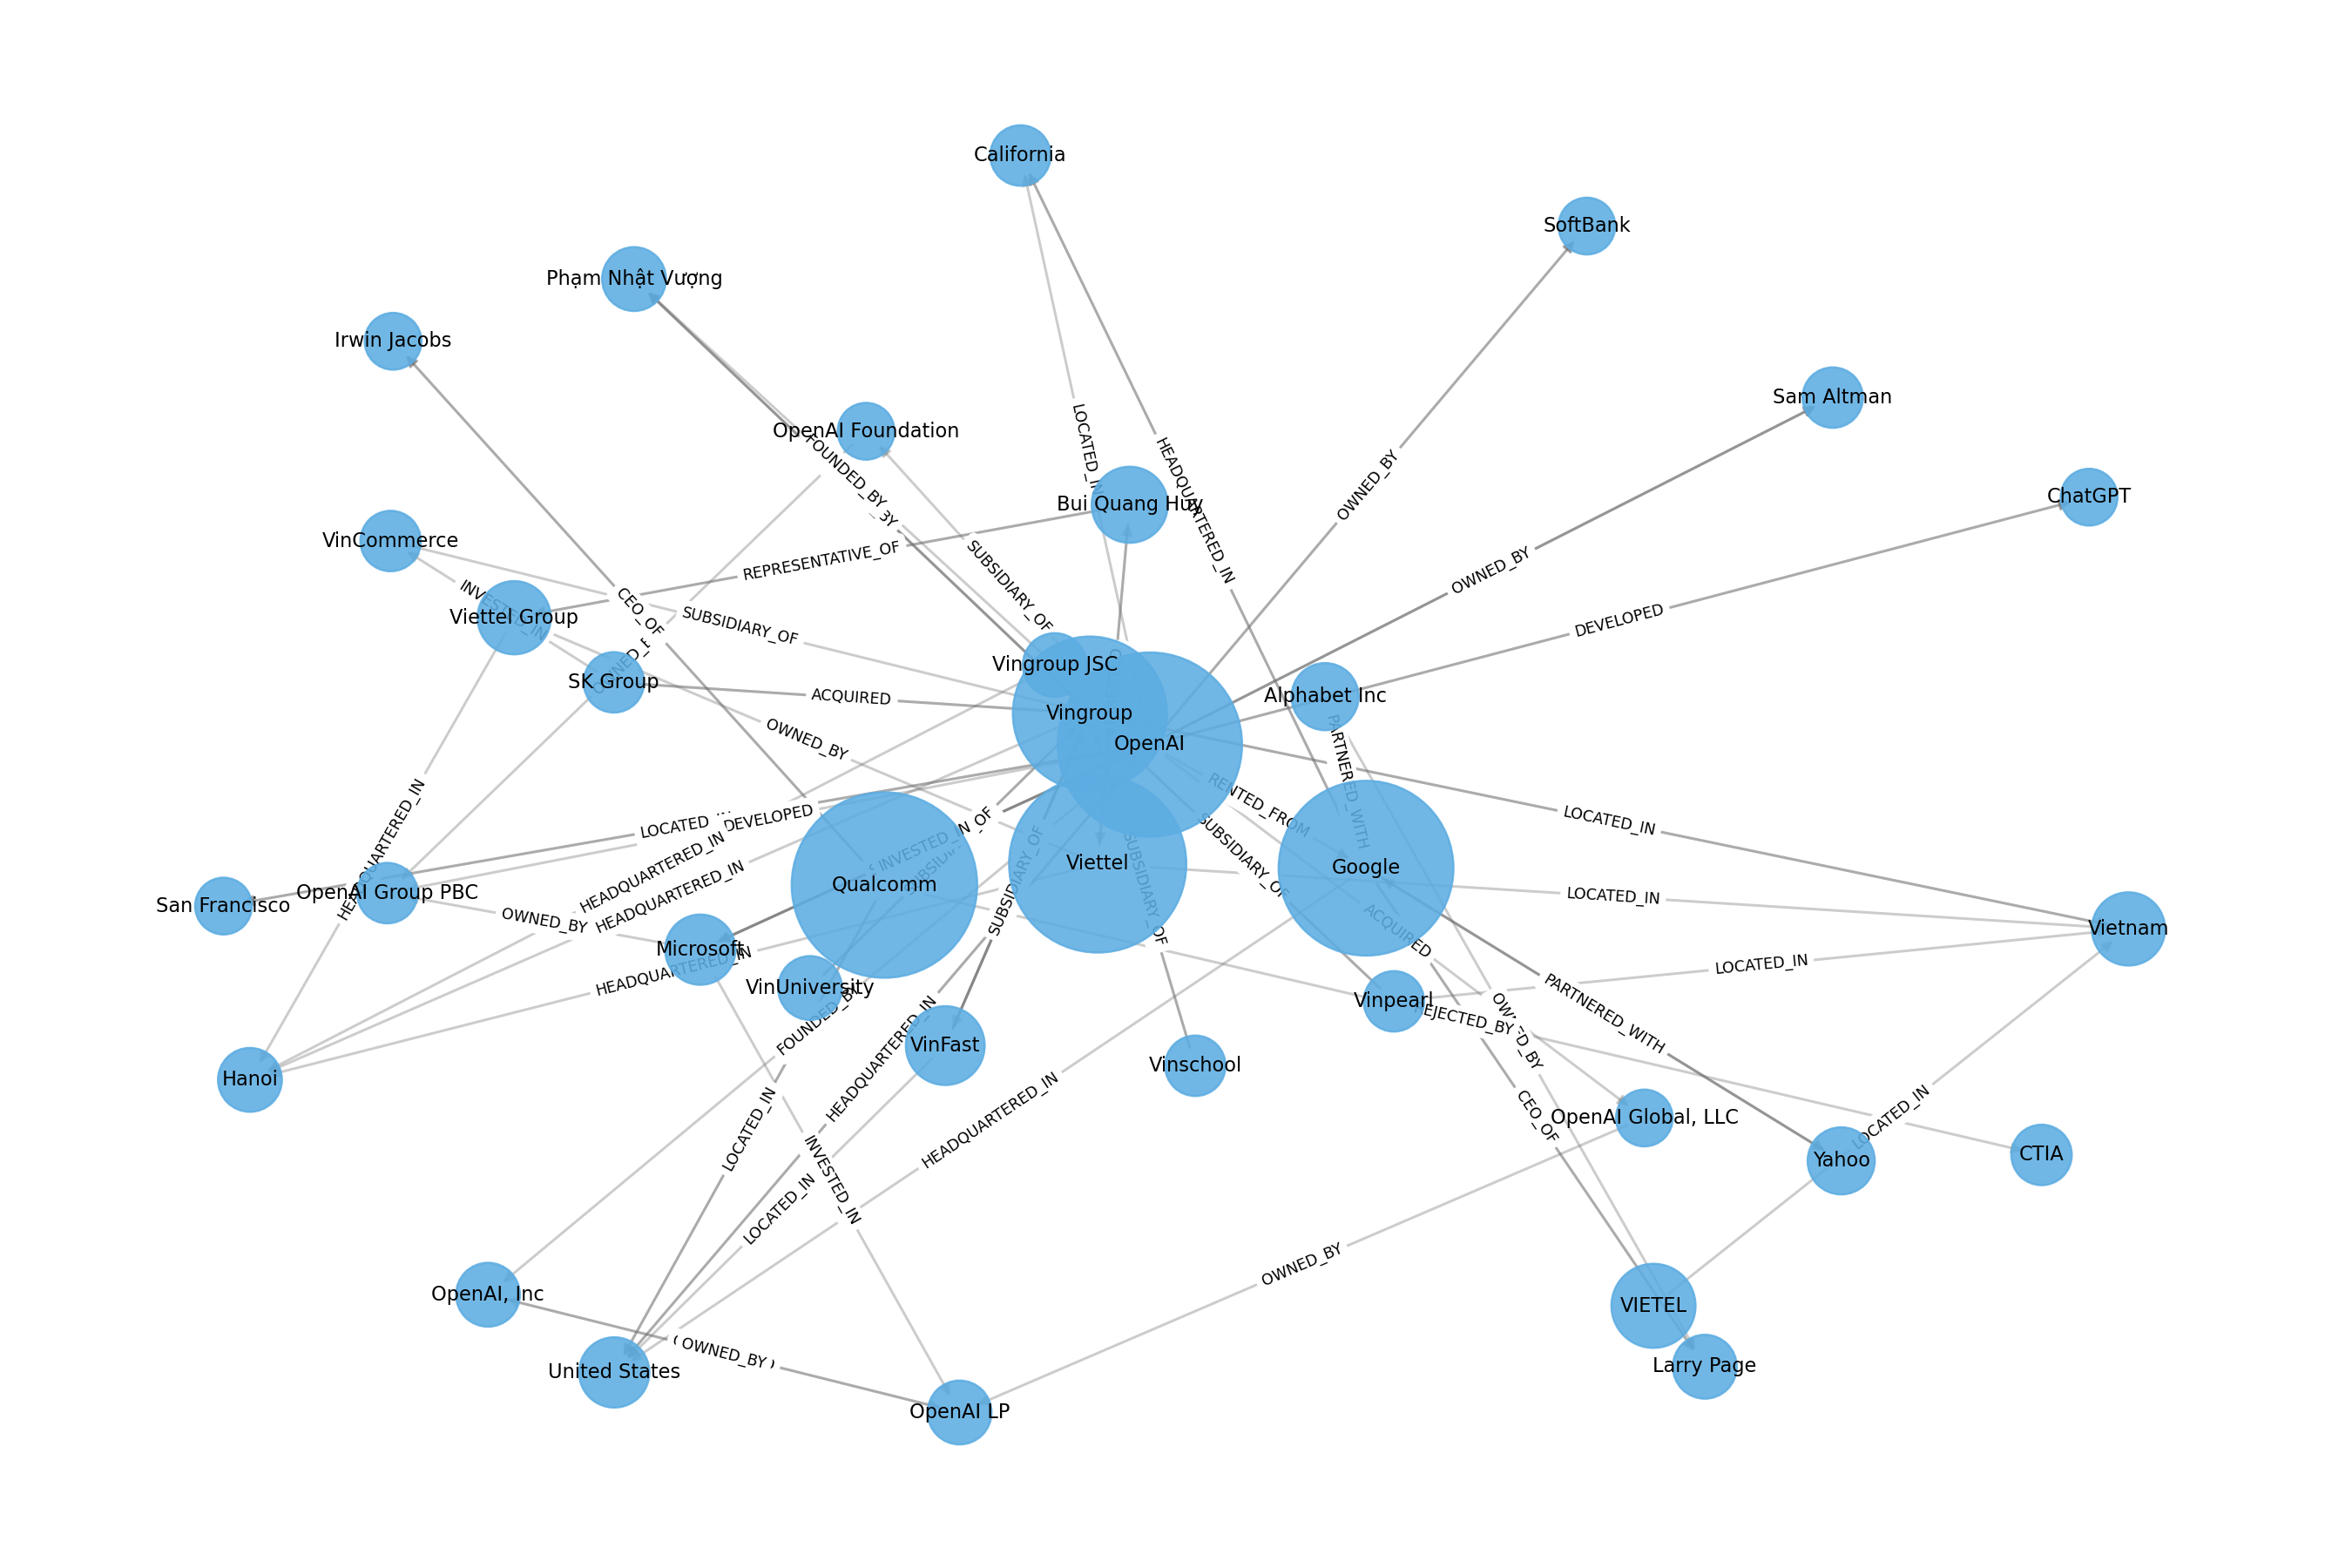

In [4]:
from IPython.display import Image, display
display(Image(filename=str(cfg.artifact_dir / 'knowledge_graph.png')))

## 4. Querying: Flat RAG vs GraphRAG

In [5]:
chunks, triples, graph = load_or_build_artifacts(cfg)
question = 'What is the relationship between OpenAI and Microsoft?'
flat = ask_flat(question, chunks, cfg)
graph_answer = ask_graph(question, graph, chunks, cfg)
flat['answer'], graph_answer['answer']

("OpenAI and Microsoft have a strategic partnership characterized by significant financial investments and collaborative projects. Microsoft has invested over $13 billion in OpenAI, including a $10 billion investment announced in January 2023. This partnership allows Microsoft to utilize OpenAI's models in its products, such as the Copilot chatbot, and provides OpenAI with cloud computing resources through Microsoft Azure. As of 2025, Microsoft owns a 27% stake in OpenAI's for-profit branch, OpenAI Group PBC, and the two companies have agreements that include revenue sharing and collaborative development opportunities. The relationship has evolved to allow both entities to pursue independent projects while maintaining their partnership.",
 "OpenAI and Microsoft have a partnership where Microsoft has invested over $13 billion into OpenAI and provides Azure cloud computing resources. Microsoft owns a 27% stake in OpenAI's for-profit entity, valued at $135 billion as of 2025. Additionally

In [6]:
import pandas as pd
pd.DataFrame([flat, graph_answer])[['mode', 'seconds', 'total_tokens', 'context_chars', 'answer']]

,mode,seconds,total_tokens,context_chars,answer
0,Flat RAG,8.824,25765,7328,OpenAI and Microsoft have a strategic partners...
1,GraphRAG,5.966,26418,9776,OpenAI and Microsoft have a partnership where ...


## 5. Benchmark 20 câu hỏi

In [7]:
rows = run_benchmark(cfg)
bench = pd.DataFrame(rows)
bench[['question', 'mode', 'seconds', 'total_tokens', 'context_chars', 'answer']].head(10)

,question,mode,seconds,total_tokens,context_chars,answer
0,Who founded OpenAI and when was it founded?,Flat RAG,3.552,25706,7328,OpenAI was founded in 2015. The founders inclu...
1,Who founded OpenAI and when was it founded?,GraphRAG,2.687,26368,9776,OpenAI was founded by Elon Musk in 2015.
2,What is the relationship between OpenAI and Mi...,Flat RAG,4.554,25766,7328,OpenAI and Microsoft have a significant partne...
3,What is the relationship between OpenAI and Mi...,GraphRAG,5.482,26425,9776,OpenAI and Microsoft have a partnership where ...
4,Which products or model families did OpenAI de...,Flat RAG,3.828,25671,7328,OpenAI developed the following products and mo...
5,Which products or model families did OpenAI de...,GraphRAG,5.811,26448,9776,OpenAI developed the following products or mod...
6,What governance change did OpenAI make in 2025?,Flat RAG,3.955,25731,7328,"In 2025, OpenAI adopted a new corporate struct..."
7,What governance change did OpenAI make in 2025?,GraphRAG,4.424,26420,9776,"In 2025, OpenAI adopted a new governance struc..."
8,What lawsuits or controversies are associated ...,Flat RAG,4.663,25786,7328,OpenAI has faced multiple lawsuits and controv...
9,What lawsuits or controversies are associated ...,GraphRAG,5.167,26438,9776,OpenAI is associated with multiple lawsuits an...


In [8]:
bench.groupby('mode')[['seconds', 'total_tokens', 'context_chars']].mean().round(2)

,seconds,total_tokens,context_chars
mode,,,
Flat RAG,5.51,25798.85,7336.60
GraphRAG,5.85,26410.00,9822.35


## 6. Phân tích ngắn

- Flat RAG phù hợp với câu hỏi đơn hop, nơi câu trả lời nằm trong một chunk gần keyword.
- GraphRAG phù hợp với câu hỏi cần nối nhiều entity/relation hoặc multi-hop.
- Khi chấm benchmark, xem cột `answer` để ghi lại trường hợp Flat RAG bị hallucination hoặc lấy sai context, trong khi GraphRAG đúng hơn nhờ facts có cấu trúc.